      ID Gioi_tinh          Que  Toan  Ngu_Van  Tieng_Anh  Diem_trung_binh  \
0      1        Nữ  Thái Nguyên   4.7      3.4        5.6             4.57   
1      2        Nữ    Khánh Hòa   7.5      7.0        9.8             8.10   
2      3       Nam       Cà Mau   9.3      7.0        5.0             7.10   
3      4        Nữ     Tây Ninh   5.3      5.3        6.1             5.57   
4      5        Nữ    Ninh Bình   6.2      5.5        4.7             5.47   
..   ...       ...          ...   ...      ...        ...              ...   
507  232        NỮ          Huế   8.0      9.1        4.4             7.17   
508  140       Nam     Lai Châu   4.4      3.8        0.0             2.73   
509   76       Nam       TP.HCM   7.7      7.4        6.3             7.13   
510   84        Nữ    Vĩnh Long   4.7      6.9        6.2             5.93   
511  240        Nữ     Lai Châu   3.1      3.7        2.6             3.13   

    Chung_chi Hoat_dong_ngoai_khoa  Thu_nhap_gd  So_ace Ket_qua

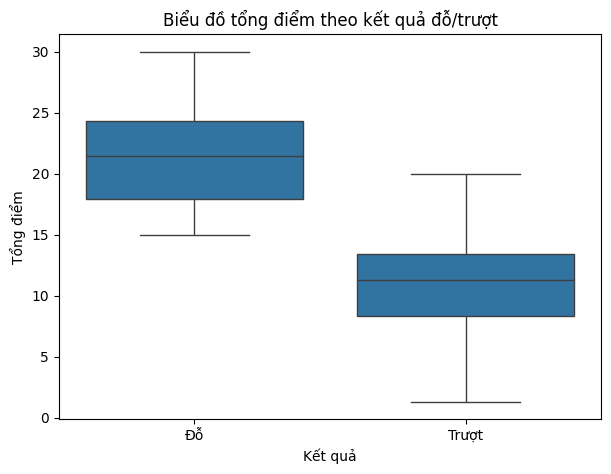

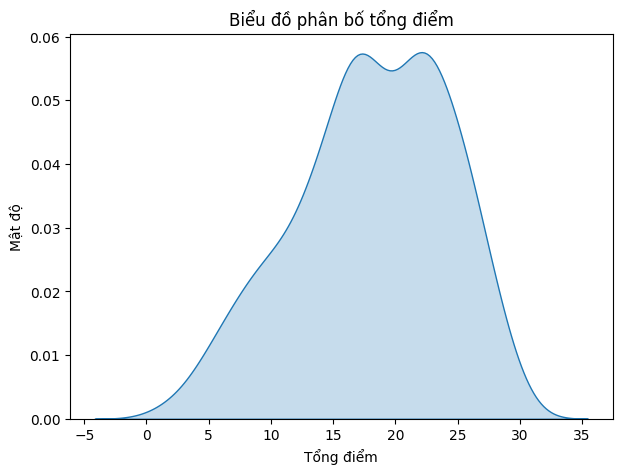

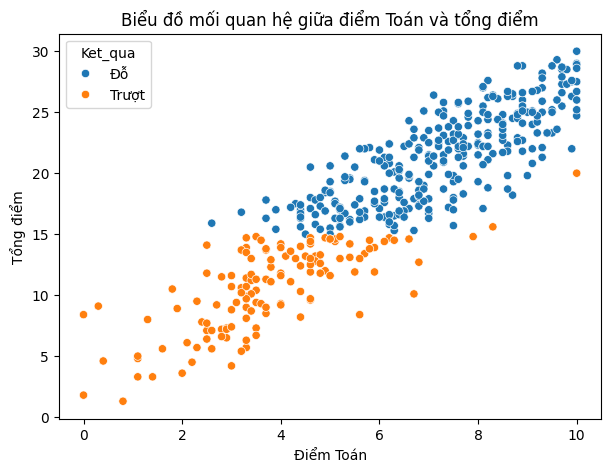

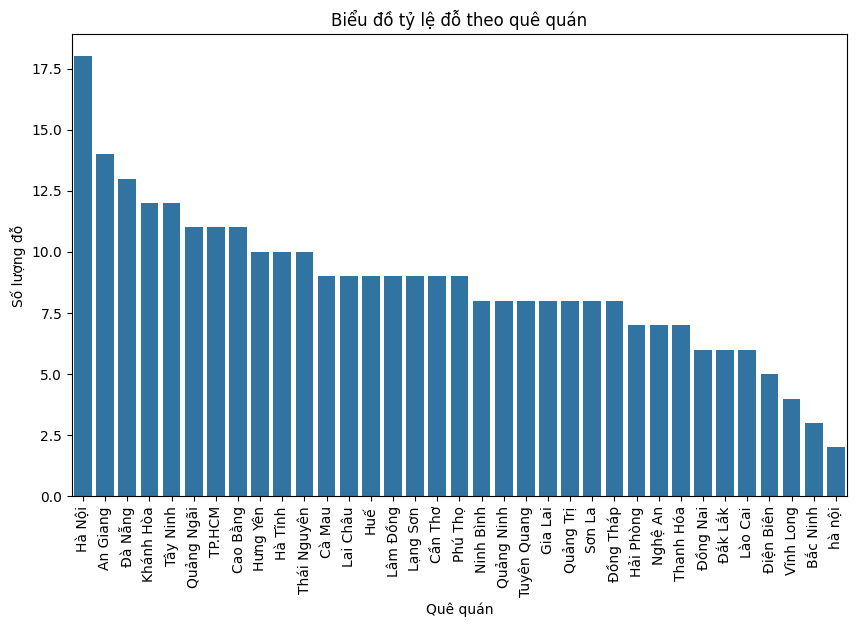

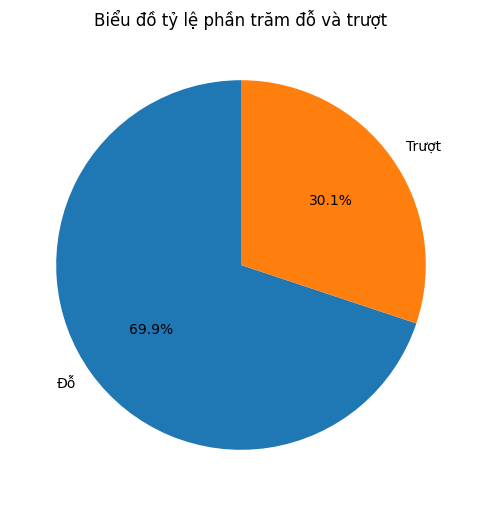

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

df = pd.read_excel(r"D:\KHDL\BTL\DLTuyenSinh.xlsx")
print(df)

print("\nDỮ LIỆU NGOẠI BIÊN\n")
print(df[df["Toan"] > 10.0])
print(df[df["Tieng_Anh"] > 10.0])
print(df[df["Ngu_Van"] > 10.0])
print(df[df["Thu_nhap_gd"] < 0])
print(df[df["So_ace"] < 0])
print(df[df["So_ace"] > 10])


#Làm sạch dữ liệu
df = df.drop_duplicates()
df[["Toan", "Ngu_Van", "Tieng_Anh"]] = df[["Toan", "Ngu_Van", "Tieng_Anh"]].fillna(0)
df = df.dropna()


#Chuẩn hóa dữ liệu
df["Tong_diem"] = df["Toan"] + df["Ngu_Van"] + df["Tieng_Anh"] #thêm cột tổng điểm
df["So_ace"] = df["So_ace"].replace(20, 2) #đổi giá trị cột Anh chị em
df["Que"] = df["Que"].replace("HN", "Hà Nội") #chuẩn hóa các dữ liệu ngoại biên
df["Que"] = df["Que"].replace("Sai Gon", "TP.HCM")
df["Hoat_dong_ngoai_khoa"] = df["Hoat_dong_ngoai_khoa"].replace("YES", "Có")
df["Hoat_dong_ngoai_khoa"] = df["Hoat_dong_ngoai_khoa"].replace("no", "Không")
df.loc[df["Tong_diem"] >= 15, "Ket_qua"] = "Đỗ" 
df.loc[df["Tong_diem"] < 15, "Ket_qua"] = "Trượt"
df.loc[(df["Toan"] <= 1) | (df["Ngu_Van"] <= 1) | (df["Tieng_Anh"] <= 1), "Ket_qua"] = "Trượt"


#loại bỏ các giá trị điểm ngoại biên 
df = df[df["Toan"] <= 10.0]
df = df[df["Tieng_Anh"] >= 0]
df = df[df["Tieng_Anh"] <= 10.0]
df = df[df["Ngu_Van"] >= 0]
df = df[df["Ngu_Van"] <= 10.0]
df = df[df["Thu_nhap_gd"] >= 0]
df = df[df["So_ace"] >= 0]

print("\nDỮ LIỆU ĐÃ LÀM SẠCH VÀ CHUẨN HÓA\n")
print(df)

#df = df.to_excel(r"D:\KHDL\BTL\CleanData.xlsx", index=False)
#print("Lưu file excel thành công.")


#Biểu đồ
plt.figure(figsize=(7,5))
sns.boxplot(x='Ket_qua', y='Tong_diem', data=df)
plt.title("Biểu đồ tổng điểm theo kết quả đỗ/trượt")
plt.xlabel("Kết quả")
plt.ylabel("Tổng điểm")
plt.show()


plt.figure(figsize=(7,5))
sns.kdeplot(df["Tong_diem"], fill=True)
plt.title("Biểu đồ phân bố tổng điểm")
plt.xlabel("Tổng điểm")
plt.ylabel("Mật độ")
plt.show()


plt.figure(figsize=(7,5))
sns.scatterplot(x='Toan', y='Tong_diem', hue='Ket_qua', data=df)
plt.title("Biểu đồ mối quan hệ giữa điểm Toán và tổng điểm")
plt.xlabel("Điểm Toán")
plt.ylabel("Tổng điểm")
plt.show()

# Lọc thí sinh đỗ
df_do = df[df['Ket_qua'] == 'Đỗ']

# Đếm số lượng đỗ theo quê quán
que_counts = df_do['Que'].value_counts().reset_index()
que_counts.columns = ['Que', 'So_luong_do']

plt.figure(figsize=(10,6))
sns.barplot(x='Que', y='So_luong_do', data=que_counts)
plt.title("Biểu đồ tỷ lệ đỗ theo quê quán")
plt.xlabel("Quê quán")
plt.ylabel("Số lượng đỗ")

# Hiển thị tên tỉnh theo chiều dọc
plt.xticks(rotation=90)
plt.show()

ketqua_counts = df['Ket_qua'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    ketqua_counts,
    labels=ketqua_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Biểu đồ tỷ lệ phần trăm đỗ và trượt")
plt.show()


